In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
!rm -rf /content/drive

In [6]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os

print(os.listdir('/content/drive/MyDrive/MyDrive/SmartHire'))

['data']


In [8]:
resume_df = pd.read_csv(
    "/content/drive/MyDrive/MyDrive/SmartHire/data/Resume.csv"
)

jobs_df = pd.read_csv(
    "/content/drive/MyDrive/MyDrive/SmartHire/data/india_job_market_2024_2026.csv"
)

extra_jobs_df = pd.read_csv(
    "/content/drive/MyDrive/MyDrive/SmartHire/data/df.csv"
)

In [9]:
print("Resume Dataset Shape:", resume_df.shape)
print("Jobs Dataset Shape:", jobs_df.shape)
print("Extra Jobs Dataset Shape:", extra_jobs_df.shape)

Resume Dataset Shape: (2484, 4)
Jobs Dataset Shape: (5000, 17)
Extra Jobs Dataset Shape: (14409, 2)


In [10]:
resume_df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [11]:
jobs_df.head()

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating,Date_Posted
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,3,276,4.0,2025-10-31
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,3,325,4.0,2025-05-19
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,5,559,3.6,2024-08-21
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3,184,3.5,2026-03-18
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,1,64,3.9,2024-10-25


In [12]:
extra_jobs_df.head()

,title,description
0,Help Desk Analyst- Tier II,Diagnose computer errors and triage to determi...
1,Clinical Research Associate II,Job Responsibilities:. . As a Clinical Res...
2,ETL Data Engineer with Oracle Data Integrator ...,Role: ETL Data Engineer with Oracle Data ...
3,OR COMM/DATA SUPPORT SPEC,Assumes primary responsibility of unit secreta...
4,Data Analyst - Intex Developer,Back to job search Data Analyst - Intex Dev...


In [13]:
print(resume_df.columns)
print(jobs_df.columns)
print(extra_jobs_df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')
Index(['Job_ID', 'Job_Title', 'Company', 'Company_Type', 'Industry', 'City',
       'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode',
       'Salary_LPA', 'Skills_Required', 'Education_Required', 'Openings',
       'Applicants', 'Company_Rating', 'Date_Posted'],
      dtype='object')
Index(['title', 'description'], dtype='object')


In [14]:
resume_df = resume_df[["Resume_str", "Category"]]

resume_df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [15]:
jobs_df = jobs_df[
    [
        "Job_Title",
        "Company",
        "City",
        "Experience_Level",
        "Skills_Required",
        "Education_Required",
    ]
]

jobs_df.head()

,Job_Title,Company,City,Experience_Level,Skills_Required,Education_Required
0,Android Developer,Tech Mahindra,Remote,Senior (6-10 yrs),"Kotlin, Java, REST APIs",M.Tech/M.E.
1,QA Engineer,Dream11,Lucknow,Senior (6-10 yrs),"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.
2,Business Analyst,HAL,Remote,Senior (6-10 yrs),"JIRA, Excel, Power BI",MCA
3,Cybersecurity Analyst,Groww,Mumbai,Mid (3-6 yrs),"Penetration Testing, Python, Ethical Hacking, ...",BCA
4,Python Developer,Oracle,Remote,Junior (1-3 yrs),"Docker, REST APIs, AWS, PostgreSQL",MCA


In [16]:
extra_jobs_df = extra_jobs_df[
    [
        "title",
        "description"
    ]
]

extra_jobs_df.head()

,title,description
0,Help Desk Analyst- Tier II,Diagnose computer errors and triage to determi...
1,Clinical Research Associate II,Job Responsibilities:. . As a Clinical Res...
2,ETL Data Engineer with Oracle Data Integrator ...,Role: ETL Data Engineer with Oracle Data ...
3,OR COMM/DATA SUPPORT SPEC,Assumes primary responsibility of unit secreta...
4,Data Analyst - Intex Developer,Back to job search Data Analyst - Intex Dev...


In [17]:
print("Resume Dataset")
print(resume_df.columns)

print("\nJob Dataset")
print(jobs_df.columns)

print("\nExtra Job Dataset")
print(extra_jobs_df.columns)

Resume Dataset
Index(['Resume_str', 'Category'], dtype='object')

Job Dataset
Index(['Job_Title', 'Company', 'City', 'Experience_Level', 'Skills_Required',
       'Education_Required'],
      dtype='object')

Extra Job Dataset
Index(['title', 'description'], dtype='object')


In [18]:
print("========== Resume Dataset ==========")
print(resume_df.isnull().sum())

print("\n========== Job Dataset ==========")
print(jobs_df.isnull().sum())

print("\n========== Extra Job Dataset ==========")
print(extra_jobs_df.isnull().sum())

========== Resume Dataset ==========
Resume_str    0
Category      0
dtype: int64

========== Job Dataset ==========
Job_Title             0
Company               0
City                  0
Experience_Level      0
Skills_Required       0
Education_Required    0
dtype: int64

========== Extra Job Dataset ==========
title          0
description    0
dtype: int64


In [19]:
print("Resume duplicates :", resume_df.duplicated().sum())

print("Job duplicates :", jobs_df.duplicated().sum())

print("Extra Job duplicates :", extra_jobs_df.duplicated().sum())

Resume duplicates : 2
Job duplicates : 0
Extra Job duplicates : 1553


In [20]:
resume_df.drop_duplicates(inplace=True)
jobs_df.drop_duplicates(inplace=True)
extra_jobs_df.drop_duplicates(inplace=True)

In [21]:
print("Resume:", resume_df.shape)
print("Jobs:", jobs_df.shape)
print("Extra Jobs:", extra_jobs_df.shape)

Resume: (2482, 2)
Jobs: (5000, 6)
Extra Jobs: (12856, 2)


In [22]:
resume_df.info()

jobs_df.info()

extra_jobs_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2482 entries, 0 to 2482
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Resume_str  2482 non-null   object
 1   Category    2482 non-null   object
dtypes: object(2)
memory usage: 58.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job_Title           5000 non-null   object
 1   Company             5000 non-null   object
 2   City                5000 non-null   object
 3   Experience_Level    5000 non-null   object
 4   Skills_Required     5000 non-null   object
 5   Education_Required  5000 non-null   object
dtypes: object(6)
memory usage: 234.5+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 12856 entries, 0 to 14408
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       ----

In [23]:
resume_df = resume_df.replace(r'^\s*$', pd.NA, regex=True)
jobs_df = jobs_df.replace(r'^\s*$', pd.NA, regex=True)
extra_jobs_df = extra_jobs_df.replace(r'^\s*$', pd.NA, regex=True)

In [24]:
print(resume_df.isnull().sum())

print(jobs_df.isnull().sum())

print(extra_jobs_df.isnull().sum())

Resume_str    1
Category      0
dtype: int64
Job_Title             0
Company               0
City                  0
Experience_Level      0
Skills_Required       0
Education_Required    0
dtype: int64
title          0
description    0
dtype: int64


In [25]:
resume_df.dropna(
    subset=["Resume_str", "Category"],
    inplace=True
)

In [26]:
jobs_df.dropna(
    subset=[
        "Job_Title",
        "Skills_Required"
    ],
    inplace=True
)

In [27]:
extra_jobs_df.dropna(
    subset=[
        "title",
        "description"
    ],
    inplace=True
)

In [28]:
resume_df.reset_index(drop=True, inplace=True)

jobs_df.reset_index(drop=True, inplace=True)

extra_jobs_df.reset_index(drop=True, inplace=True)

In [29]:
print(resume_df.shape)
print(jobs_df.shape)
print(extra_jobs_df.shape)

print(resume_df.head())
print(jobs_df.head())
print(extra_jobs_df.head())

(2481, 2)
(5000, 6)
(12856, 2)
                                          Resume_str Category
0           HR ADMINISTRATOR/MARKETING ASSOCIATE\...       HR
1           HR SPECIALIST, US HR OPERATIONS      ...       HR
2           HR DIRECTOR       Summary      Over 2...       HR
3           HR SPECIALIST       Summary    Dedica...       HR
4           HR MANAGER         Skill Highlights  ...       HR
               Job_Title        Company     City   Experience_Level  \
0      Android Developer  Tech Mahindra   Remote  Senior (6-10 yrs)   
1            QA Engineer        Dream11  Lucknow  Senior (6-10 yrs)   
2       Business Analyst            HAL   Remote  Senior (6-10 yrs)   
3  Cybersecurity Analyst          Groww   Mumbai      Mid (3-6 yrs)   
4       Python Developer         Oracle   Remote   Junior (1-3 yrs)   

                                     Skills_Required Education_Required  
0                            Kotlin, Java, REST APIs        M.Tech/M.E.  
1  Selenium, Manual Te

In [30]:
resume_df.info()

jobs_df.info()

extra_jobs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2481 entries, 0 to 2480
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Resume_str  2481 non-null   object
 1   Category    2481 non-null   object
dtypes: object(2)
memory usage: 38.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job_Title           5000 non-null   object
 1   Company             5000 non-null   object
 2   City                5000 non-null   object
 3   Experience_Level    5000 non-null   object
 4   Skills_Required     5000 non-null   object
 5   Education_Required  5000 non-null   object
dtypes: object(6)
memory usage: 234.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12856 entries, 0 to 12855
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------ 

In [31]:
category_counts = resume_df["Category"].value_counts()

print(category_counts)

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      119
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   117
FITNESS                   117
SALES                     116
AVIATION                  116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


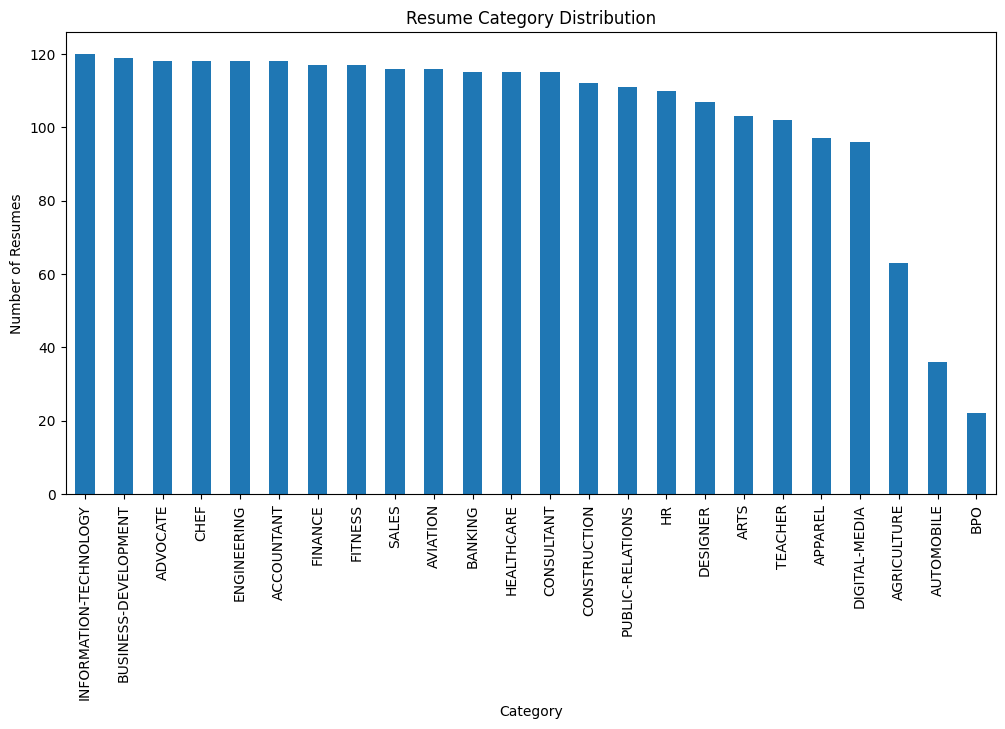

In [32]:
plt.figure(figsize=(12,6))

category_counts.plot(kind="bar")

plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Resumes")

plt.xticks(rotation=90)

plt.show()

In [33]:
experience_counts=jobs_df["Experience_Level"].value_counts()
print(experience_counts)

Experience_Level
Mid (3-6 yrs)        1378
Junior (1-3 yrs)     1256
Fresher (0-1 yr)     1022
Senior (6-10 yrs)     831
Lead (10+ yrs)        513
Name: count, dtype: int64


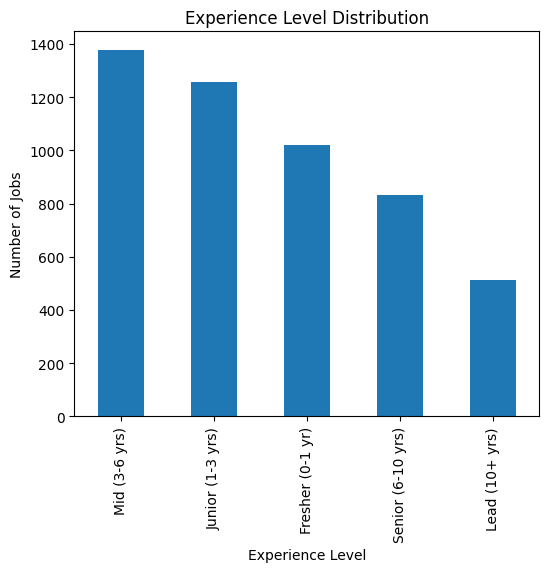

In [34]:
plt.figure(figsize=(6,5))

experience_counts.plot(kind="bar")

plt.title("Experience Level Distribution")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")

plt.show()

In [35]:
education_counts = jobs_df["Education_Required"].value_counts()

print(education_counts)

Education_Required
B.Tech/B.E.              2000
M.Tech/M.E.               927
MCA                       584
BCA                       509
B.Sc (CS/IT)              402
MBA                       308
B.Com + Certification     174
PhD                        96
Name: count, dtype: int64


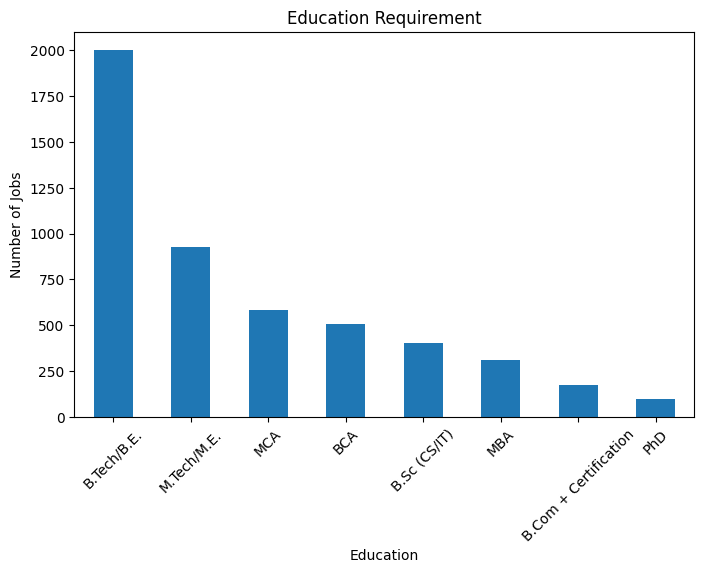

In [36]:
plt.figure(figsize=(8,5))

education_counts.plot(kind="bar")

plt.title("Education Requirement")
plt.xlabel("Education")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.show()

In [37]:
city_counts = jobs_df["City"].value_counts().head(10)

print(city_counts)

City
Remote         1992
Mumbai          372
Pune            371
Hyderabad       359
Bangalore       344
Chennai         322
Delhi           318
Indore          103
Bhubaneswar     101
Lucknow          98
Name: count, dtype: int64


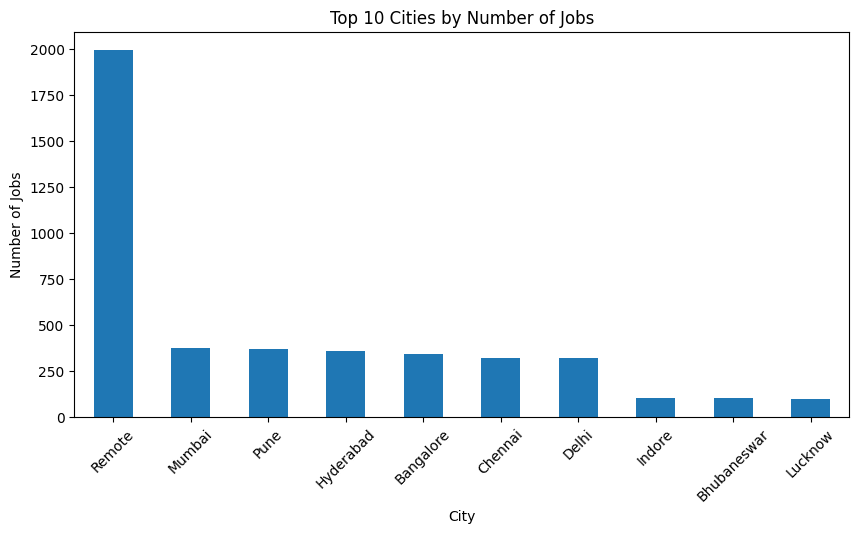

In [38]:
plt.figure(figsize=(10,5))

city_counts.plot(kind="bar")

plt.title("Top 10 Cities by Number of Jobs")
plt.xlabel("City")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.show()

In [39]:
from collections import Counter

all_skills = []

for skills in jobs_df["Skills_Required"]:
    skill_list = skills.split(",")

    for skill in skill_list:
        all_skills.append(skill.strip())

In [40]:
skill_counts = Counter(all_skills)

top_skills = skill_counts.most_common(20)

top_skills

[('Python', 1579),
 ('REST APIs', 998),
 ('AWS', 867),
 ('SQL', 847),
 ('Docker', 836),
 ('Java', 636),
 ('PostgreSQL', 455),
 ('React', 454),
 ('TypeScript', 440),
 ('Agile', 429),
 ('JavaScript', 419),
 ('MongoDB', 416),
 ('Node.js', 415),
 ('Power BI', 388),
 ('Excel', 387),
 ('Kubernetes', 385),
 ('System Design', 359),
 ('JIRA', 346),
 ('Statistics', 343),
 ('TensorFlow', 325)]

In [41]:
skills_df = pd.DataFrame(
    top_skills,
    columns=["Skill","Count"]
)

skills_df

,Skill,Count
0,Python,1579
1,REST APIs,998
2,AWS,867
3,SQL,847
4,Docker,836
5,Java,636
6,PostgreSQL,455
7,React,454
8,TypeScript,440
9,Agile,429


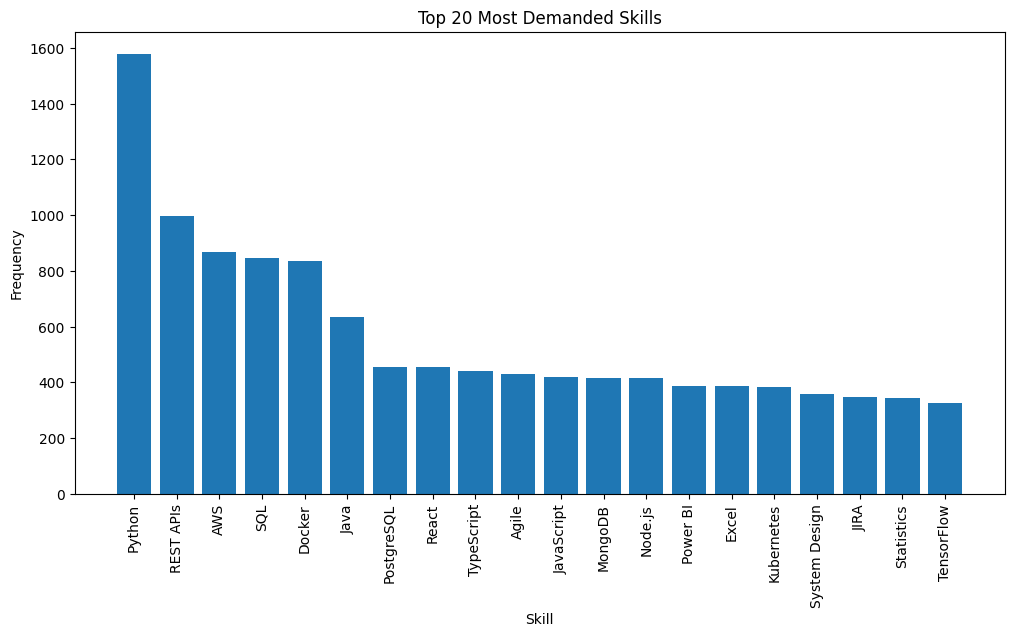

In [42]:
plt.figure(figsize=(12,6))

plt.bar(skills_df["Skill"], skills_df["Count"])

plt.title("Top 20 Most Demanded Skills")
plt.xlabel("Skill")
plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.show()

In [43]:
# Create processed data folder if it doesn't exist
import os

processed_path = "/content/drive/MyDrive/MyDrive/SmartHire/data/processed"
os.makedirs(processed_path, exist_ok=True)

In [44]:
resume_df.to_csv(
    "/content/drive/MyDrive/MyDrive/SmartHire/data/processed/resume_clean.csv",
    index=False
)

jobs_df.to_csv(
    "/content/drive/MyDrive/MyDrive/SmartHire/data/processed/jobs_clean.csv",
    index=False
)

extra_jobs_df.to_csv(
    "/content/drive/MyDrive/MyDrive/SmartHire/data/processed/extra_jobs_clean.csv",
    index=False
)

print("✅ Cleaned datasets saved successfully!")

✅ Cleaned datasets saved successfully!
